# Text-Only MLP Baseline — CMU-MOSEI

Text-only sentiment regression baseline using the BERT embedding cache from the MuLT notebook.  
Metrics are identical (MAE, Pearson r, Acc2) so results are directly comparable.

**Model:** 4-layer MLP operating directly on the 768-dim BERT vector.  
A static BERT embedding is a single fixed representation, not a sequence — an MLP is the correct architecture here.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Load Data ──────────────────────────────────────────────────────────────────
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

sid, entry = next(iter(aligned['train'].items()))
print(f"\nSample ID: {sid}")
print(f"  Label:      {entry['label']:.4f}")
bert_vec = bert_cache.get(sid, None)
print(f"  BERT shape: {np.array(bert_vec).shape if bert_vec is not None else 'MISSING'}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852

Sample ID: -3g5yACwYnA[0]
  Label:      1.0000
  BERT shape: (768,)


In [ ]:
# ── Dataset ────────────────────────────────────────────────────────────────────
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

def clean_vec(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)


class TextOnlyDataset(Dataset):
    """
    Returns the full 768-dim BERT vector and label.
    noise_level adds Gaussian noise to the BERT embedding (for robustness eval).
    """
    def __init__(self, split_dict, bert_cache, noise_level=0.0):
        self.items       = list(split_dict.items())
        self.bert        = bert_cache
        self.noise_level = noise_level

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        text  = clean_vec(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(float(entry['label']), nan=0.0), -3.0, 3.0))
        if self.noise_level > 0:
            text = text + np.random.randn(*text.shape).astype(np.float32) * self.noise_level
        return torch.from_numpy(text), torch.tensor(label)


BATCH = 32
train_ds = TextOnlyDataset(aligned['train'], bert_cache)
valid_ds = TextOnlyDataset(aligned['valid'], bert_cache)
test_ds  = TextOnlyDataset(aligned['test'],  bert_cache)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoaders ready. Train batches: {len(train_loader)}  Valid: {len(valid_loader)}")
x, y = next(iter(train_loader))
print(f"Batch text shape: {x.shape}  label shape: {y.shape}")

DataLoaders ready. Train batches: 511  Valid: 59
Batch text shape: torch.Size([32, 768])  label shape: torch.Size([32])


In [ ]:
# ── Model ──────────────────────────────────────────────────────────────────────
import torch.nn as nn

class TextOnlyMLP(nn.Module):
    """
    4-layer MLP on the full 768-dim BERT vector.
    A static BERT embedding is not a sequence — MLP is the right architecture.
    """
    def __init__(self, d_in=768, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256),  nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),  nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, text):  # text: (B, 768)
        return self.net(text).squeeze(-1)  # (B,)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = TextOnlyMLP().to(device)
print(f"Device: {device}")
print(f"TextOnlyMLP params: {sum(p.numel() for p in model.parameters()):,}")
dummy = torch.randn(4, 768).to(device)
print(f"Output shape: {model(dummy).shape}  (expected (4,))")

Device: cuda
TextOnlyMLP params: 559,873
Output shape: torch.Size([4])  (expected (4,))


In [ ]:
# ── Training ───────────────────────────────────────────────────────────────────
import torch.nn.functional as F
import numpy as np

EPOCHS        = 80
LR            = 3e-4   # higher than MuLT — MLP on static embeddings needs a stronger LR
WARMUP_EPOCHS = 5
PATIENCE      = 25
LAMBDA_SIGN   = 0.3    # same sign-agreement auxiliary loss as MuLT notebook

model = TextOnlyMLP().to(device)
opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
mse   = nn.MSELoss()

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

def sign_loss(pred, labels):
    return F.binary_cross_entropy(torch.sigmoid(pred * 5.0), (labels >= 0).float())

def safe_loss(t):
    return None if (torch.isnan(t) or torch.isinf(t)) else t

best_val_mae   = float('inf')
epochs_no_impr = 0
history        = {'train_loss': [], 'val_mae': []}

print(f"Training TextOnlyMLP on {device}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}  |  Epochs: {EPOCHS}  |  LR: {LR}")
print("-" * 72)

for epoch in range(1, EPOCHS + 1):
    model.train()
    loss_sum, n_batches, n_skip = 0.0, 0, 0

    for text, labels in train_loader:
        text, labels = text.to(device), labels.to(device)
        if torch.isnan(text).any() or torch.isnan(labels).any():
            continue
        opt.zero_grad()
        preds = model(text)
        loss  = safe_loss(mse(preds, labels) + LAMBDA_SIGN * sign_loss(preds, labels))
        if loss is None:
            n_skip += 1
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        loss_sum  += loss.item()
        n_batches += 1

    sched.step()

    model.eval()
    vp, vl = [], []
    with torch.no_grad():
        for text, labels in valid_loader:
            vp.append(torch.nan_to_num(model(text.to(device)), nan=0.0).cpu())
            vl.append(labels)
    if not vp:
        continue

    vp, vl   = torch.cat(vp), torch.cat(vl)
    val_mae  = (vp - vl).abs().mean().item()
    avg_loss = loss_sum / n_batches if n_batches else float('nan')
    history['train_loss'].append(avg_loss)
    history['val_mae'].append(val_mae)

    if not np.isnan(val_mae) and val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), CSD_DIR + 'best_text_only.pt')
        epochs_no_impr = 0
    else:
        epochs_no_impr += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  LR={opt.param_groups[0]['lr']:.2e}  "
              f"Loss={avg_loss:.4f}  ValMAE={val_mae:.4f}  "
              f"Best={best_val_mae:.4f}  NoImpr={epochs_no_impr}")

    if epochs_no_impr >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE: {best_val_mae:.4f}")

Training TextOnlyMLP on cuda
Params: 559,873  |  Epochs: 80  |  LR: 0.0003
------------------------------------------------------------------------
Epoch   1/80  LR=1.20e-04  Loss=1.4728  ValMAE=0.7777  Best=0.7777  NoImpr=0
Epoch   5/80  LR=3.00e-04  Loss=1.4553  ValMAE=0.7777  Best=0.7777  NoImpr=0
Epoch  10/80  LR=2.97e-04  Loss=1.4517  ValMAE=0.7778  Best=0.7776  NoImpr=4
Epoch  15/80  LR=2.87e-04  Loss=1.4473  ValMAE=0.7781  Best=0.7776  NoImpr=9
Epoch  20/80  LR=2.71e-04  Loss=1.4503  ValMAE=0.7777  Best=0.7776  NoImpr=14
Epoch  25/80  LR=2.50e-04  Loss=1.4466  ValMAE=0.7777  Best=0.7776  NoImpr=19
Epoch  30/80  LR=2.25e-04  Loss=1.4480  ValMAE=0.7778  Best=0.7776  NoImpr=24

Early stopping at epoch 31.

Done. Best Val MAE: 0.7776


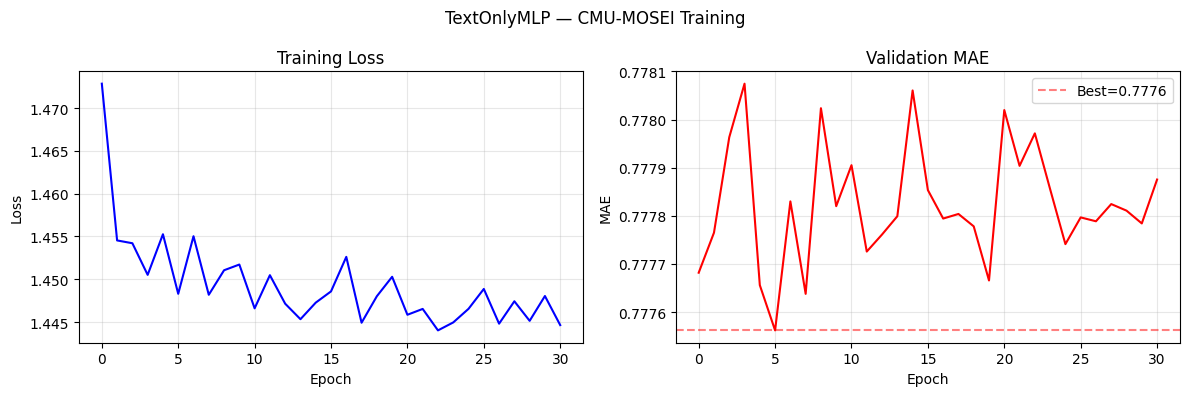

In [ ]:
# ── Training Curves ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], 'b-')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(history['val_mae'], 'r-')
ax2.axhline(best_val_mae, color='r', linestyle='--', alpha=0.5, label=f'Best={best_val_mae:.4f}')
ax2.set_title('Validation MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('TextOnlyMLP — CMU-MOSEI Training')
plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_training_curves.png', dpi=150)
plt.show()

── Clean Test ──────────────────────────────────
TextOnlyMLP  MAE=0.8402  Corr=-0.0050  Acc2=0.7102

Pred  — mean: 0.093  std: 0.000
Labels — mean: 0.142  std: 1.109

⚠️  WARNING: std of predictions is very low — model may have collapsed.
   Try increasing LR further or checking that BERT vectors are non-trivial.


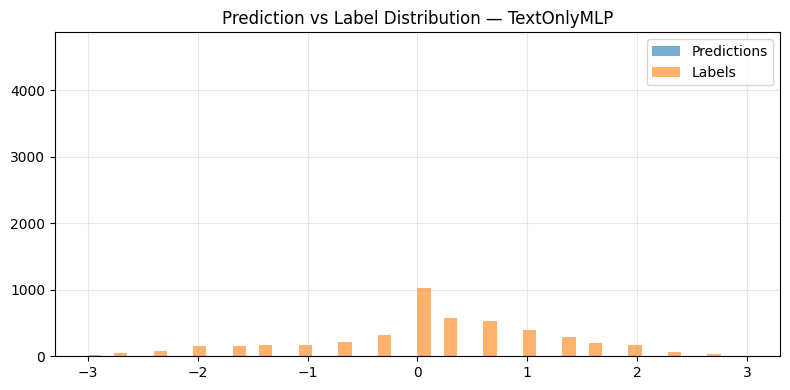

In [ ]:
# ── Test Evaluation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(CSD_DIR + 'best_text_only.pt', map_location=device))
model.eval()

def evaluate(split_dict, noise_level=0.0):
    ds  = TextOnlyDataset(split_dict, bert_cache, noise_level=noise_level)
    ldr = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=2)
    preds, labels_all = [], []
    with torch.no_grad():
        for text, labels in ldr:
            preds.append(torch.nan_to_num(model(text.to(device)), nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds).numpy()
    labels_all = torch.cat(labels_all).numpy()
    mae  = float(np.abs(preds - labels_all).mean())
    corr = float(np.corrcoef(preds, labels_all)[0, 1])
    acc2 = float(((preds >= 0) == (labels_all >= 0)).mean())
    return mae, corr, acc2, preds, labels_all


mae, corr, acc2, preds, labels_all = evaluate(aligned['test'])
print("── Clean Test ──────────────────────────────────")
print(f"TextOnlyMLP  MAE={mae:.4f}  Corr={corr:.4f}  Acc2={acc2:.4f}")
print(f"\nPred  — mean: {preds.mean():.3f}  std: {preds.std():.3f}")
print(f"Labels — mean: {labels_all.mean():.3f}  std: {labels_all.std():.3f}")
if preds.std() < 0.05:
    print("\n⚠️  WARNING: std of predictions is very low — model may have collapsed.")
    print("   Try increasing LR further or checking that BERT vectors are non-trivial.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(preds,      bins=50, alpha=0.6, label='Predictions')
ax.hist(labels_all, bins=50, alpha=0.6, label='Labels')
ax.set_title('Prediction vs Label Distribution — TextOnlyMLP')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_pred_dist.png', dpi=150)
plt.show()

── Text Noise Robustness ───────────────────────
 Noise       MAE      Corr      Acc2
   0.0    0.8402   -0.0050    0.7102
   0.3    0.8459   -0.0115    0.7049
   0.5    0.8540    0.0061    0.7008
   0.8    0.8629   -0.0009    0.7006
   1.0    0.8620    0.0064    0.7014


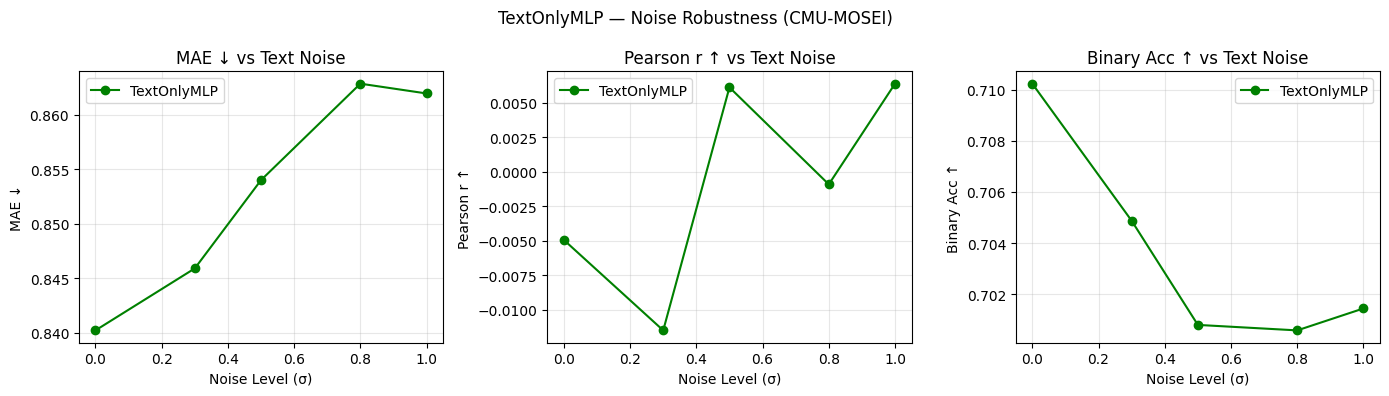

In [ ]:
# ── Text Noise Robustness ──────────────────────────────────────────────────────
# Gaussian noise added to the 768-dim BERT vector.
# Comparable to noise_modality='text' in the MuLT notebook.

noise_levels  = [0.0, 0.3, 0.5, 0.8, 1.0]
results_noise = {'mae': [], 'corr': [], 'acc2': []}

print("── Text Noise Robustness ───────────────────────")
print(f"{'Noise':>6}  {'MAE':>8}  {'Corr':>8}  {'Acc2':>8}")
for nl in noise_levels:
    m, r, a, _, _ = evaluate(aligned['test'], noise_level=nl)
    results_noise['mae'].append(m)
    results_noise['corr'].append(r)
    results_noise['acc2'].append(a)
    print(f"{nl:>6.1f}  {m:>8.4f}  {r:>8.4f}  {a:>8.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key, ylabel in zip(axes, ['mae','corr','acc2'], ['MAE ↓','Pearson r ↑','Binary Acc ↑']):
    ax.plot(noise_levels, results_noise[key], 'g-o', label='TextOnlyMLP')
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs Text Noise')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('TextOnlyMLP — Noise Robustness (CMU-MOSEI)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_noise_robustness.png', dpi=150)
plt.show()

In [ ]:
# ── Comparison Table ───────────────────────────────────────────────────────────
# Fill in BaselineMuLT and AdaptiveMuLTv5 numbers from MuLT_v3.ipynb.

rows = [
    ('TextOnlyMLP',    'Text only',           mae,   corr,  acc2),
    ('BaselineMuLT',   'Audio+Video+Text',     None,  None,  None),  # <- fill in
    ('AdaptiveMuLTv5', 'Audio+Video+Text',     None,  None,  None),  # <- fill in
]

def fmt(v): return f"{v:.4f}" if v is not None else '  ----'

print(f"{'Model':<22}  {'Modalities':<22}  {'MAE':>8}  {'Corr':>8}  {'Acc2':>8}")
print("-" * 74)
for name, mods, m, r, a in rows:
    print(f"{name:<22}  {mods:<22}  {fmt(m):>8}  {fmt(r):>8}  {fmt(a):>8}")

Model                   Modalities                   MAE      Corr      Acc2
--------------------------------------------------------------------------
TextOnlyMLP             Text only                 0.8402   -0.0050    0.7102
BaselineMuLT            Audio+Video+Text            ----      ----      ----
AdaptiveMuLTv5          Audio+Video+Text            ----      ----      ----


## Qualitative Analysis — Missing Modality Recovery

These cells explore **which samples the text-only model recovers well** (implying text alone is sufficient for those utterances) and **where it fails** (implying audio/video carry the sentiment signal). This gives an intuition for what the multimodal models gain over text-only.

In [ ]:
# ── Collect per-sample predictions and errors ──────────────────────────────
# Run this after loading best_text_only.pt in the eval cell above.

import numpy as np
import torch
from torch.utils.data import DataLoader

model.load_state_dict(torch.load(CSD_DIR + 'best_text_only.pt', map_location=device))
model.eval()

# Collect sid, true label, predicted label for every test sample
test_items = list(aligned['test'].items())
test_sids  = [sid for sid, _ in test_items]

all_preds, all_labels = [], []
with torch.no_grad():
    for text, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2):
        all_preds.append(torch.nan_to_num(model(text.to(device)), nan=0.0).cpu())
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_errors = np.abs(all_preds - all_labels)

def sentiment_label(v):
    if v > 0.5:  return 'positive'
    if v < -0.5: return 'negative'
    return 'neutral'

true_sentiments = np.array([sentiment_label(l) for l in all_labels])
pred_sentiments = np.array([sentiment_label(p) for p in all_preds])

print(f'Test samples: {len(all_preds)}')
print(f'MAE: {all_errors.mean():.4f}  Std: {all_errors.std():.4f}')
print(f'Pred std: {all_preds.std():.4f}  (non-trivial if > 0.1)')
for s in ['positive', 'neutral', 'negative']:
    mask = true_sentiments == s
    print(f'  {s:>8}: {mask.sum():4d} samples  MAE={all_errors[mask].mean():.4f}')


Test samples: 4659
MAE: 0.8402  Std: 0.7249
Pred std: 0.0000  (non-trivial if > 0.1)
  positive: 1709 samples  MAE=1.1315
   neutral: 1927 samples  MAE=0.1937
  negative: 1023 samples  MAE=1.5714


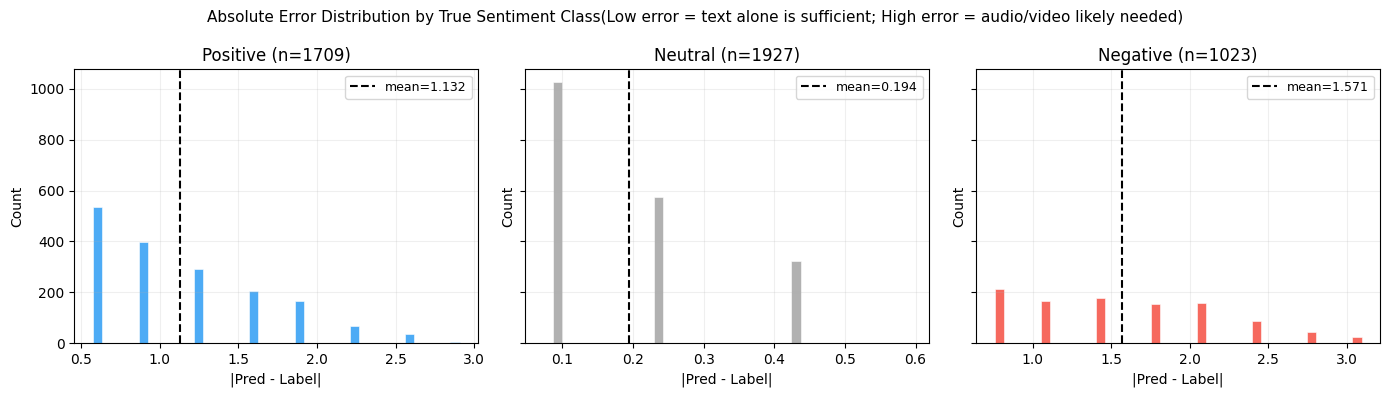

In [ ]:
# ── 1. Error distribution by sentiment class ───────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = {'positive': '#2196F3', 'neutral': '#9E9E9E', 'negative': '#F44336'}

for ax, sent in zip(axes, ['positive', 'neutral', 'negative']):
    mask = true_sentiments == sent
    errs = all_errors[mask]
    ax.hist(errs, bins=40, color=colors[sent], alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(errs.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'mean={errs.mean():.3f}')
    ax.set_title(f'{sent.capitalize()} (n={mask.sum()})', fontsize=12)
    ax.set_xlabel('|Pred - Label|')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('Absolute Error Distribution by True Sentiment Class'
             '(Low error = text alone is sufficient; High error = audio/video likely needed)',
             fontsize=11)
plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_error_by_class.png', dpi=150)
plt.show()


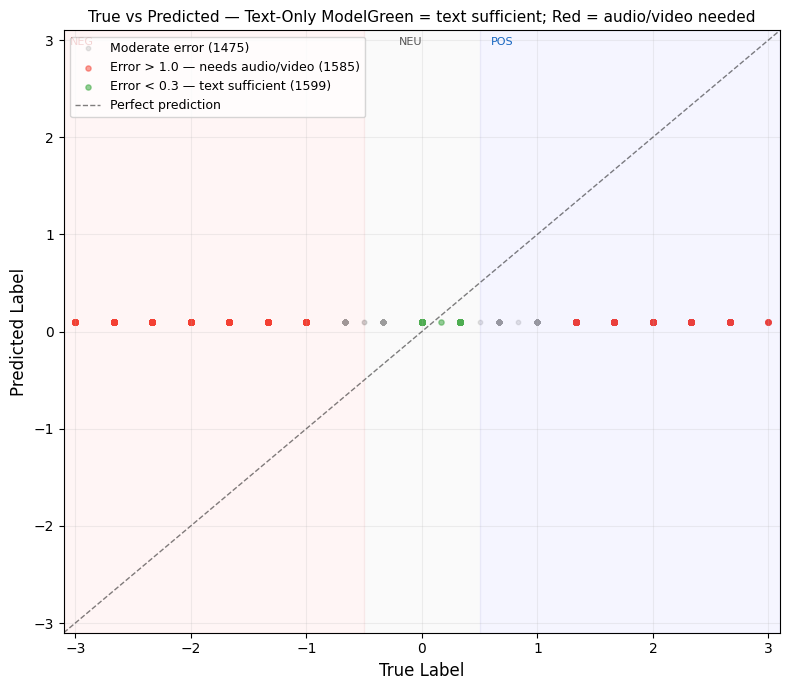

Text sufficient  (err < 0.3): 1599 samples (34.3%)
Moderate         (err in between): 1475 samples (31.7%)
Needs AV         (err > 1.0):  1585 samples (34.0%)


In [ ]:
# ── 2. True label vs predicted — scatter coloured by recovery quality ──────
# Well-recovered = |error| < 0.3  (text alone captures the sentiment)
# Poorly-recovered = |error| > 1.0  (audio/video likely needed)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

GOOD_THR = 0.3
BAD_THR  = 1.0

good_mask = all_errors < GOOD_THR
bad_mask  = all_errors > BAD_THR
mid_mask  = ~good_mask & ~bad_mask

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(all_labels[mid_mask],  all_preds[mid_mask],  alpha=0.25, s=10,
           color='#9E9E9E', label=f'Moderate error ({mid_mask.sum()})')
ax.scatter(all_labels[bad_mask],  all_preds[bad_mask],  alpha=0.5,  s=14,
           color='#F44336', label=f'Error > {BAD_THR} — needs audio/video ({bad_mask.sum()})')
ax.scatter(all_labels[good_mask], all_preds[good_mask], alpha=0.6,  s=14,
           color='#4CAF50', label=f'Error < {GOOD_THR} — text sufficient ({good_mask.sum()})')

# Perfect prediction line
lim = max(abs(all_labels).max(), abs(all_preds).max()) + 0.1
ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, alpha=0.5, label='Perfect prediction')

# Sentiment region shading
ax.axvspan(-lim, -0.5, alpha=0.04, color='red')
ax.axvspan(-0.5,  0.5, alpha=0.04, color='grey')
ax.axvspan( 0.5,  lim, alpha=0.04, color='blue')
ax.text(-lim + 0.05, lim - 0.15, 'NEG', fontsize=8, color='#c62828')
ax.text(-0.2,        lim - 0.15, 'NEU', fontsize=8, color='#555')
ax.text( 0.6,        lim - 0.15, 'POS', fontsize=8, color='#1565C0')

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('True Label', fontsize=12)
ax.set_ylabel('Predicted Label', fontsize=12)
ax.set_title('True vs Predicted — Text-Only Model'
             'Green = text sufficient; Red = audio/video needed', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_scatter.png', dpi=150)
plt.show()

print(f'Text sufficient  (err < {GOOD_THR}): {good_mask.sum():4d} samples ({100*good_mask.mean():.1f}%)')
print(f'Moderate         (err in between): {mid_mask.sum():4d} samples ({100*mid_mask.mean():.1f}%)')
print(f'Needs AV         (err > {BAD_THR}):  {bad_mask.sum():4d} samples ({100*bad_mask.mean():.1f}%)')


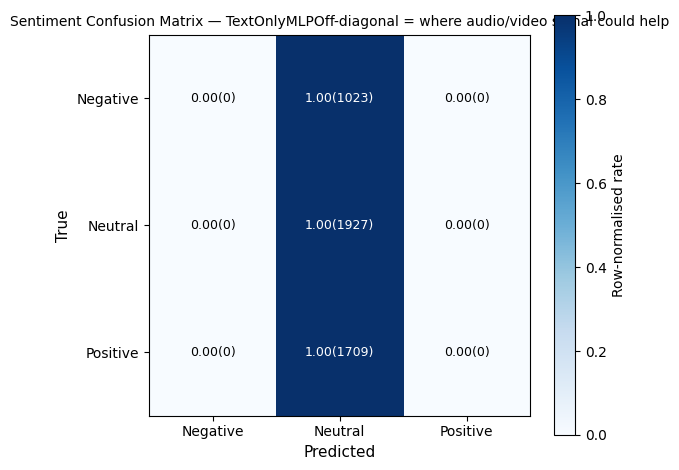

3-class accuracy: 0.4136
  negative  recall=0.000  precision=0.000
   neutral  recall=1.000  precision=0.414
  positive  recall=0.000  precision=0.000


In [ ]:
# ── 3. Sentiment confusion matrix ─────────────────────────────────────────
# Shows where the text-only model makes systematic classification errors.
# Off-diagonal cells are where adding audio/video could help most.

import matplotlib.pyplot as plt
import numpy as np

classes   = ['negative', 'neutral', 'positive']
n_classes = len(classes)
cm = np.zeros((n_classes, n_classes), dtype=int)

cls_idx = {c: i for i, c in enumerate(classes)}
for t, p in zip(true_sentiments, pred_sentiments):
    cm[cls_idx[t], cls_idx[p]] += 1

fig, ax = plt.subplots(figsize=(6, 5))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Row-normalised rate')

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels([c.capitalize() for c in classes])
ax.set_yticklabels([c.capitalize() for c in classes])
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title('Sentiment Confusion Matrix — TextOnlyMLP'
             'Off-diagonal = where audio/video signal could help', fontsize=10)

for i in range(n_classes):
    for j in range(n_classes):
        color = 'white' if cm_norm[i, j] > 0.6 else 'black'
        ax.text(j, i, f'{cm_norm[i,j]:.2f}({cm[i,j]})',
                ha='center', va='center', fontsize=9, color=color)

plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_confusion.png', dpi=150)
plt.show()

acc3 = cm.diagonal().sum() / cm.sum()
print(f'3-class accuracy: {acc3:.4f}')
for i, c in enumerate(classes):
    recall    = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    precision = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
    print(f'  {c:>8}  recall={recall:.3f}  precision={precision:.3f}')


In [ ]:
# ── 4. Best and worst recovered samples ────────────────────────────────────
# Best  = samples the text-only model nails  → text is the dominant signal
# Worst = samples the model misses badly      → audio/video carry the sentiment

import numpy as np

N_SHOW = 15
sorted_idx = np.argsort(all_errors)
best_idx   = sorted_idx[:N_SHOW]
worst_idx  = sorted_idx[-N_SHOW:][::-1]

def show_samples(indices, title):
    print(f'{"=" * 72}')
    print(f' {title}')
    print(f'{"=" * 72}')
    print(f'  {"SID":<40}  {"True":>6}  {"Pred":>6}  {"Err":>6}  {"True class":>10}  {"Pred class":>10}')
    print(f'  {"-" * 40}  {"-" * 6}  {"-" * 6}  {"-" * 6}  {"-" * 10}  {"-" * 10}')
    for i in indices:
        sid   = test_sids[i]
        short = sid[-38:] if len(sid) > 38 else sid
        print(f'  {short:<40}  {all_labels[i]:>6.3f}  {all_preds[i]:>6.3f}  '
              f'{all_errors[i]:>6.3f}  {true_sentiments[i]:>10}  {pred_sentiments[i]:>10}')

show_samples(best_idx,  'BEST RECOVERED  (text alone captures sentiment)')
show_samples(worst_idx, 'WORST RECOVERED (audio/video likely carry the signal)')


 BEST RECOVERED  (text alone captures sentiment)
  SID                                         True    Pred     Err  True class  Pred class
  ----------------------------------------  ------  ------  ------  ----------  ----------
  y3r2kk8zvl0[5]                             0.167   0.093   0.074     neutral     neutral
  -yRb-Jum7EQ[1]                             0.000   0.093   0.093     neutral     neutral
  -yRb-Jum7EQ[2]                             0.000   0.093   0.093     neutral     neutral
  -yRb-Jum7EQ[4]                             0.000   0.093   0.093     neutral     neutral
  0JaYazphxfM[1]                             0.000   0.093   0.093     neutral     neutral
  0K7dCp80n9c[2]                             0.000   0.093   0.093     neutral     neutral
  0K7dCp80n9c[4]                             0.000   0.093   0.093     neutral     neutral
  0K7dCp80n9c[5]                             0.000   0.093   0.093     neutral     neutral
  0K7dCp80n9c[6]                         

Sign error rate (on non-neutral samples): 0.3745 (1023 / 2732)
Sign error rate — positive utterances: 0.0000
Sign error rate — negative utterances: 1.0000


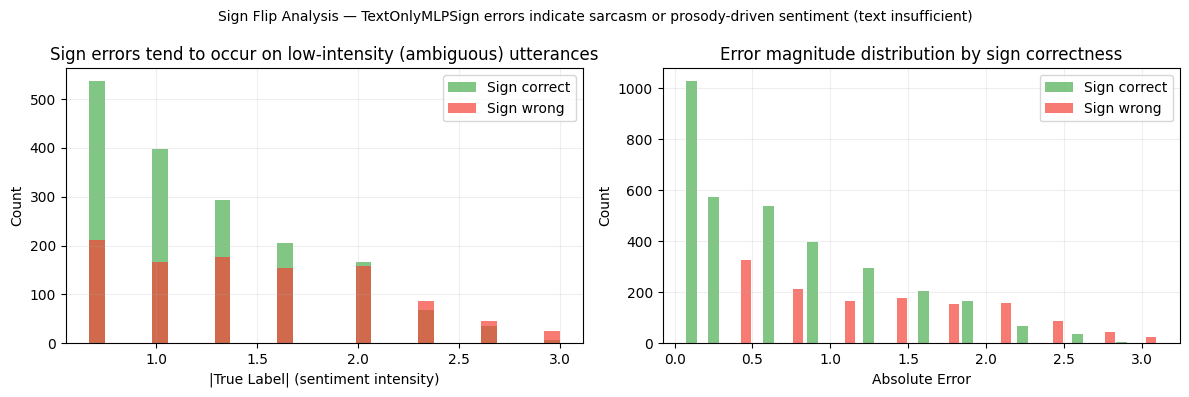

In [ ]:
# ── 5. Sign flip analysis: where text-only gets the sign wrong ────────────
# Sign errors (predicting positive when label is negative and vice versa)
# are the most damaging failures — these are the utterances where
# vocal tone / facial expression directly contradicts the word content.

import matplotlib.pyplot as plt
import numpy as np

correct_sign = (all_preds >= 0) == (all_labels >= 0)
wrong_sign   = ~correct_sign

# Only consider non-neutral ground truths (neutral is ambiguous for sign)
non_neutral  = true_sentiments != 'neutral'
sign_err_rate = wrong_sign[non_neutral].mean()

print(f'Sign error rate (on non-neutral samples): {sign_err_rate:.4f} ({wrong_sign[non_neutral].sum()} / {non_neutral.sum()})')
print(f'Sign error rate — positive utterances: '
      f'{wrong_sign[true_sentiments == "positive"].mean():.4f}')
print(f'Sign error rate — negative utterances: '
      f'{wrong_sign[true_sentiments == "negative"].mean():.4f}')

# Distribution of true label magnitudes for sign-correct vs sign-wrong
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: label magnitude distribution
axes[0].hist(np.abs(all_labels[correct_sign & non_neutral]),
             bins=30, alpha=0.7, color='#4CAF50', label='Sign correct')
axes[0].hist(np.abs(all_labels[wrong_sign & non_neutral]),
             bins=30, alpha=0.7, color='#F44336', label='Sign wrong')
axes[0].set_xlabel('|True Label| (sentiment intensity)')
axes[0].set_ylabel('Count')
axes[0].set_title('Sign errors tend to occur on low-intensity (ambiguous) utterances')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Right: error magnitude for sign-correct vs sign-wrong
axes[1].hist(all_errors[correct_sign], bins=40, alpha=0.7, color='#4CAF50', label='Sign correct')
axes[1].hist(all_errors[wrong_sign],   bins=40, alpha=0.7, color='#F44336', label='Sign wrong')
axes[1].set_xlabel('Absolute Error')
axes[1].set_ylabel('Count')
axes[1].set_title('Error magnitude distribution by sign correctness')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.suptitle('Sign Flip Analysis — TextOnlyMLP'
             'Sign errors indicate sarcasm or prosody-driven sentiment (text insufficient)',
             fontsize=10)
plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_sign_flip.png', dpi=150)
plt.show()


Mean train BERT vec computed from 16322 samples.


/tmp/ipykernel_21380/2873250174.py:31: RuntimeWarning: Mean of empty slice.
  mean_errs = [all_errors[bin_idx == b].mean() for b in range(4)]
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


ValueError: Axis limits cannot be NaN or Inf

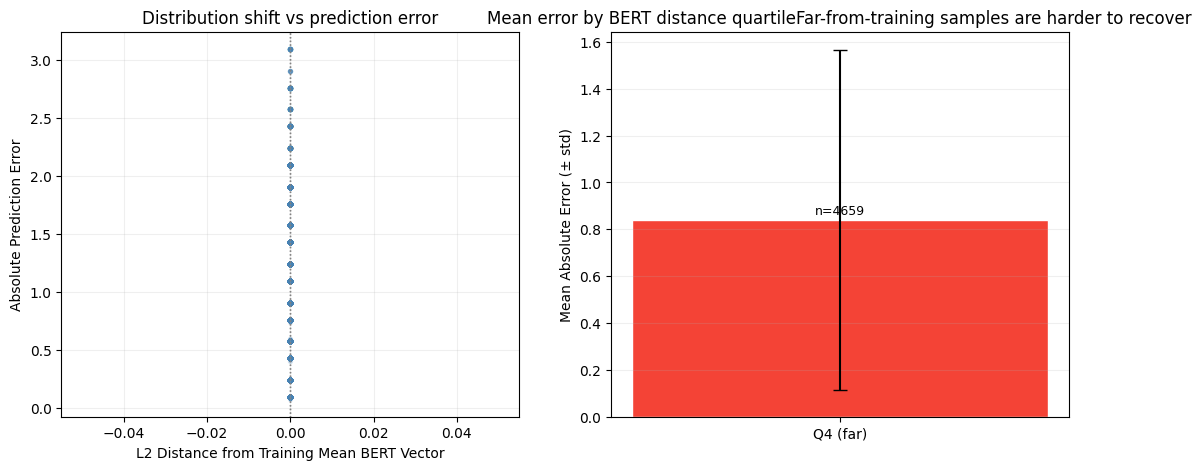

In [ ]:
# ── 6. BERT embedding similarity vs prediction error ──────────────────────
# Tests whether samples with unusual BERT representations (far from the
# training distribution) are harder for the text-only model to recover.
# High distance + high error = the model has no text signal to work from.

import numpy as np
import matplotlib.pyplot as plt

# Compute mean training BERT vector
train_sids = [sid for sid, _ in aligned['train'].items()]
train_vecs = np.stack([
    bert_cache.get(sid, np.zeros(768, dtype=np.float32))
    for sid in train_sids
], dtype=np.float32)
mean_train_vec = train_vecs.mean(axis=0)
print(f'Mean train BERT vec computed from {len(train_sids)} samples.')

# L2 distance of each test sample from the training mean
test_vecs = np.stack([
    bert_cache.get(sid, np.zeros(768, dtype=np.float32))
    for sid in test_sids
], dtype=np.float32)
l2_dists = np.linalg.norm(test_vecs - mean_train_vec, axis=1)

# Bin by distance quartile and show mean error per bin
quartiles  = np.percentile(l2_dists, [25, 50, 75])
bin_labels = ['Q1 (close)', 'Q2', 'Q3', 'Q4 (far)']
bins       = [-np.inf] + list(quartiles) + [np.inf]
bin_idx    = np.digitize(l2_dists, quartiles)  # 0–3

mean_errs = [all_errors[bin_idx == b].mean() for b in range(4)]
std_errs  = [all_errors[bin_idx == b].std()  for b in range(4)]
counts    = [(bin_idx == b).sum()             for b in range(4)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter — distance vs error
axes[0].scatter(l2_dists, all_errors, alpha=0.2, s=8, color='steelblue')
axes[0].set_xlabel('L2 Distance from Training Mean BERT Vector')
axes[0].set_ylabel('Absolute Prediction Error')
axes[0].set_title('Distribution shift vs prediction error')
axes[0].grid(True, alpha=0.2)

# Add quartile reference lines
for q, label in zip(quartiles, ['Q1', 'Q2', 'Q3']):
    axes[0].axvline(q, color='grey', linestyle=':', linewidth=1, alpha=0.7)

# Right: bar chart of mean error per quartile
bars = axes[1].bar(bin_labels, mean_errs, yerr=std_errs,
                   color=['#4CAF50', '#8BC34A', '#FF9800', '#F44336'],
                   edgecolor='white', capsize=5)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01, f'n={count}',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Mean Absolute Error (± std)')
axes[1].set_title('Mean error by BERT distance quartile'
                  'Far-from-training samples are harder to recover')
axes[1].grid(True, alpha=0.2, axis='y')
axes[1].set_ylim(0, max(mean_errs) * 1.3)

plt.suptitle('BERT Embedding Distribution Shift — TextOnlyMLP', fontsize=11)
plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_bert_shift.png', dpi=150)
plt.show()

print('Mean error by BERT distance quartile:')
for lbl, me, se, cnt in zip(bin_labels, mean_errs, std_errs, counts):
    print(f'  {lbl:<12}  MAE={me:.4f} ± {se:.4f}  (n={cnt})')


## Missing Modality Analysis

These cells probe what happens when the text signal is **partially or fully absent**.
Since this is a text-only model, zeroing the input is the equivalent of asking:
*"what does the model fall back to when it has no signal?"*

This mirrors the `modality_dropout` analysis in the MuLT notebook and gives a
meaningful lower bound to compare against the multimodal model's recovery.

In [ ]:
# ── Setup: build arrays we'll reuse across analysis cells ───────────────────
# Run this once after the Test Evaluation cell (Cell 7).
import numpy as np
import torch
from torch.utils.data import DataLoader

model.eval()

test_sids   = [sid for sid, _ in aligned['test'].items()]
test_labels = np.array([
    float(np.clip(np.nan_to_num(float(entry['label']), nan=0.0), -3.0, 3.0))
    for _, entry in aligned['test'].items()
])

def get_preds(split_dict, noise_level=0.0, zero_text=False):
    """Return numpy predictions for a split.
    zero_text=True replaces every BERT vector with zeros (fully missing text)."""
    ds  = TextOnlyDataset(split_dict, bert_cache, noise_level=noise_level)
    ldr = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=2)
    preds = []
    with torch.no_grad():
        for text, _ in ldr:
            if zero_text:
                text = torch.zeros_like(text)
            out = torch.nan_to_num(model(text.to(device)), nan=0.0).cpu()
            preds.append(out)
    return torch.cat(preds).numpy()

noise_levels   = [0.0, 0.3, 0.5, 0.8, 1.0]
preds_by_noise = {nl: get_preds(aligned['test'], noise_level=nl) for nl in noise_levels}
preds_zero     = get_preds(aligned['test'], zero_text=True)   # fully missing text
clean_preds    = preds_by_noise[0.0]
all_errors     = np.abs(clean_preds - test_labels)

print('Predictions collected for all conditions.')
print(f'  Clean     MAE={all_errors.mean():.4f}')
print(f'  Zero-text MAE={np.abs(preds_zero - test_labels).mean():.4f}  '
      f'(model with NO text signal)')


Predictions collected for all conditions.
  Clean     MAE=0.8402
  Zero-text MAE=0.8402  (model with NO text signal)


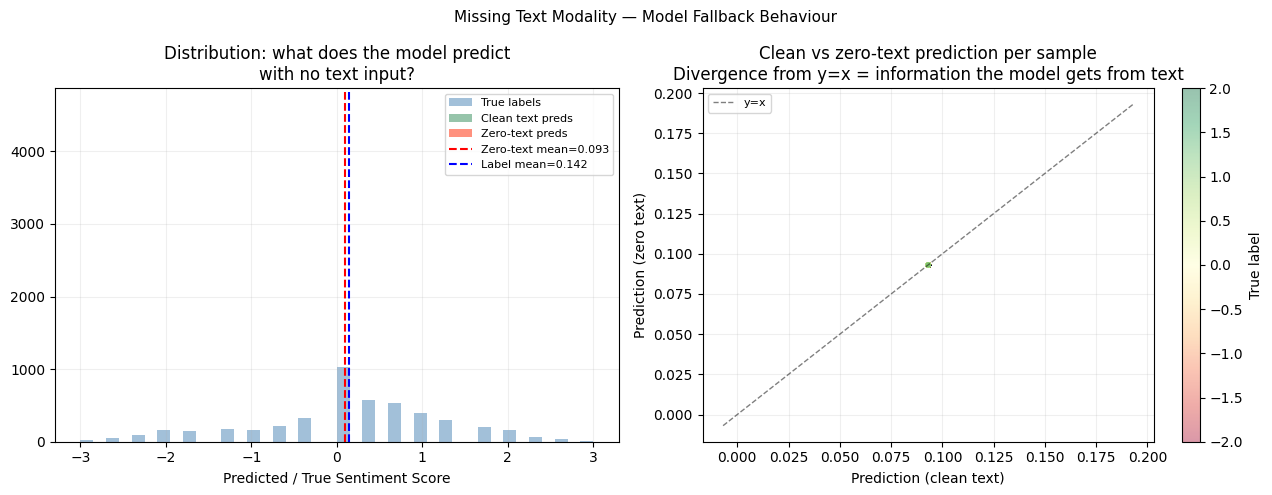

Mean shift from zero-text to clean: 0.0000
  i.e. on average, text moves the prediction by 0.0000 sentiment units
Zero-text sign acc: 0.7102  (label prior baseline)
Clean-text sign acc: 0.7102


In [ ]:
# ── 1. What does the model output with zero text? ───────────────────────────
# When the input is all zeros the model has no linguistic signal.
# We expect it to regress toward the training label mean.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: distribution of zero-text vs clean predictions vs labels
axes[0].hist(test_labels,   bins=40, alpha=0.5, label='True labels',      color='steelblue')
axes[0].hist(clean_preds,   bins=40, alpha=0.5, label='Clean text preds', color='seagreen')
axes[0].hist(preds_zero,    bins=40, alpha=0.7, label='Zero-text preds',  color='tomato')
axes[0].axvline(preds_zero.mean(), color='red', linestyle='--',
                label=f'Zero-text mean={preds_zero.mean():.3f}')
axes[0].axvline(test_labels.mean(), color='blue', linestyle='--',
                label=f'Label mean={test_labels.mean():.3f}')
axes[0].set_title('Distribution: what does the model predict\nwith no text input?')
axes[0].set_xlabel('Predicted / True Sentiment Score')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

# Right: per-sample scatter — clean pred vs zero-text pred, coloured by true label
sc = axes[1].scatter(clean_preds, preds_zero, c=test_labels,
                     cmap='RdYlGn', alpha=0.4, s=10, vmin=-2, vmax=2)
plt.colorbar(sc, ax=axes[1], label='True label')
lo = min(clean_preds.min(), preds_zero.min()) - 0.1
hi = max(clean_preds.max(), preds_zero.max()) + 0.1
axes[1].plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5, label='y=x')
axes[1].set_xlabel('Prediction (clean text)')
axes[1].set_ylabel('Prediction (zero text)')
axes[1].set_title('Clean vs zero-text prediction per sample\n'
                  'Divergence from y=x = information the model gets from text')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

plt.suptitle('Missing Text Modality — Model Fallback Behaviour', fontsize=11)
plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_zero_text.png', dpi=150)
plt.show()

# Stats
pred_shift = np.abs(clean_preds - preds_zero)
print(f'Mean shift from zero-text to clean: {pred_shift.mean():.4f}')
print(f'  i.e. on average, text moves the prediction by {pred_shift.mean():.4f} sentiment units')
print(f'Zero-text sign acc: {((preds_zero>=0)==(test_labels>=0)).mean():.4f}  '
      f'(label prior baseline)')
print(f'Clean-text sign acc: {((clean_preds>=0)==(test_labels>=0)).mean():.4f}')


Sample breakdown (4659 total test samples):
  Consistently correct across all noise levels: 3024 (64.9%)
  Degrading (correct clean, wrong zero-text):   0 (0.0%)
  Unrecovered (wrong at all levels):            1223 (26.3%)


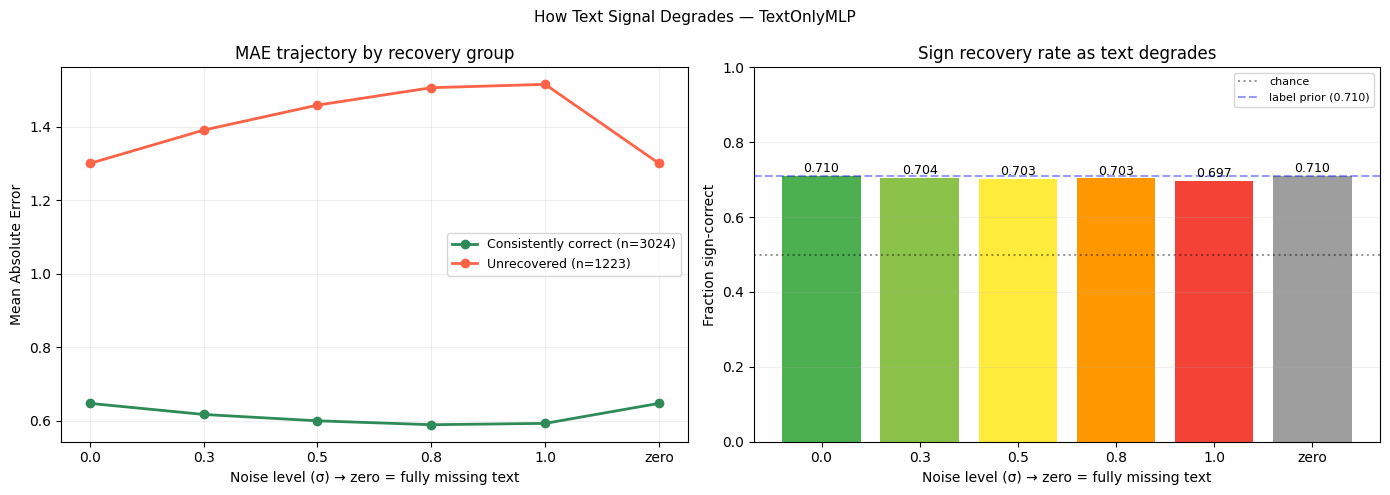

In [ ]:
# ── 2. Per-sample noise trajectory ──────────────────────────────────────────
# For each sample, track how its prediction changes as text noise increases.
# Three groups:
#   - Consistently correct (sign correct at all noise levels)
#   - Degrading (correct at low noise, wrong at high noise)
#   - Unrecovered (wrong at all noise levels)
import matplotlib.pyplot as plt

all_levels   = noise_levels + ['zero']
preds_all    = [preds_by_noise[nl] for nl in noise_levels] + [preds_zero]
signs_all    = np.stack([(p >= 0) for p in preds_all], axis=1)  # (N, 6)
true_sign    = (test_labels >= 0)                                 # (N,)
correct_all  = signs_all == true_sign[:, None]                    # (N, 6)

consistent   = correct_all.all(axis=1)    # always right
unrecovered  = (~correct_all).all(axis=1) # always wrong
degrading    = correct_all[:, 0] & ~correct_all[:, -1]  # right at 0, wrong at zero-text

print(f'Sample breakdown ({len(test_labels)} total test samples):')
print(f'  Consistently correct across all noise levels: {consistent.sum()} ({consistent.mean()*100:.1f}%)')
print(f'  Degrading (correct clean, wrong zero-text):   {degrading.sum()} ({degrading.mean()*100:.1f}%)')
print(f'  Unrecovered (wrong at all levels):            {unrecovered.sum()} ({unrecovered.mean()*100:.1f}%)')

# Plot mean absolute error trajectory per group
x_labels = [str(nl) for nl in noise_levels] + ['zero']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mask, label, color in [
    (consistent,  'Consistently correct', 'seagreen'),
    (degrading,   'Degrading',            'orange'),
    (unrecovered, 'Unrecovered',          'tomato'),
]:
    if mask.sum() == 0:
        continue
    mae_per_level = [np.abs(preds_all[i][mask] - test_labels[mask]).mean()
                     for i in range(len(all_levels))]
    axes[0].plot(x_labels, mae_per_level, 'o-', label=f'{label} (n={mask.sum()})',
                 color=color, linewidth=2, markersize=6)

axes[0].set_xlabel('Noise level (σ) → zero = fully missing text')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_title('MAE trajectory by recovery group')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Right: fraction of samples sign-correct at each level
frac_correct = correct_all.mean(axis=0)
axes[1].bar(x_labels, frac_correct,
            color=['#4CAF50','#8BC34A','#FFEB3B','#FF9800','#F44336','#9E9E9E'])
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Noise level (σ) → zero = fully missing text')
axes[1].set_ylabel('Fraction sign-correct')
axes[1].set_title('Sign recovery rate as text degrades')
for i, v in enumerate(frac_correct):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
axes[1].axhline(0.5, color='black', linestyle=':', alpha=0.4, label='chance')
axes[1].axhline((test_labels>=0).mean(), color='blue', linestyle='--', alpha=0.4,
                label=f'label prior ({(test_labels>=0).mean():.3f})')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2, axis='y')

plt.suptitle('How Text Signal Degrades — TextOnlyMLP', fontsize=11)
plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_recovery_trajectory.png', dpi=150)
plt.show()


In [ ]:
# ── 3. Per-sample recovery table (qualitative examples) ──────────────────────
# Shows individual utterances and what the model predicts under each condition.
# Picks interesting cases: samples that degrade, surprise recoveries, etc.
import pandas as pd

def sentiment_str(score):
    if score >  0.5: return 'positive'
    if score < -0.5: return 'negative'
    return 'neutral'

def recovery_tag(true_lbl, pred_clean, pred_noisy, pred_zero):
    true_sign  = true_lbl >= 0
    clean_ok   = (pred_clean >= 0) == true_sign
    noisy_ok   = (pred_noisy >= 0) == true_sign
    zero_ok    = (pred_zero  >= 0) == true_sign
    if clean_ok and noisy_ok and zero_ok:  return 'robust ✓'
    if clean_ok and noisy_ok and not zero_ok: return 'needs text ↓'
    if clean_ok and not noisy_ok:          return 'fragile ⚡'
    if not clean_ok:                       return 'wrong ✗'
    return 'mixed'

noise_mid   = preds_by_noise[0.5]
noise_high  = preds_by_noise[1.0]

rows = []
for i, sid in enumerate(test_sids):
    rows.append({
        'utterance_id':    sid,
        'true_label':      round(float(test_labels[i]), 3),
        'true_sentiment':  sentiment_str(test_labels[i]),
        'pred_clean':      round(float(clean_preds[i]),  3),
        'pred_noise_0.5':  round(float(noise_mid[i]),    3),
        'pred_noise_1.0':  round(float(noise_high[i]),   3),
        'pred_zero_text':  round(float(preds_zero[i]),   3),
        'recovery':        recovery_tag(test_labels[i], clean_preds[i],
                                        noise_mid[i], preds_zero[i]),
    })

df = pd.DataFrame(rows)

# ── Print one table per recovery category ────────────────────────────────────
N_SHOW = 8
for tag in ['robust ✓', 'needs text ↓', 'fragile ⚡', 'wrong ✗']:
    subset = df[df['recovery'] == tag]
    if len(subset) == 0:
        continue
    # Sort: robust by abs error asc; others by abs error desc for most interesting
    subset = subset.copy()
    subset['abs_err'] = (subset['pred_clean'] - subset['true_label']).abs()
    ascending = (tag == 'robust ✓')
    subset = subset.sort_values('abs_err', ascending=ascending).head(N_SHOW)
    print(f'\n── {tag} ({len(df[df["recovery"]==tag])} samples) ──────────────────────────────')
    print(subset[['utterance_id','true_label','true_sentiment',
                   'pred_clean','pred_noise_0.5','pred_noise_1.0',
                   'pred_zero_text']].to_string(index=False))

print(f'\nRecovery distribution across {len(df)} test samples:')
print(df['recovery'].value_counts().to_string())



── robust ✓ (3239 samples) ──────────────────────────────
   utterance_id  true_label true_sentiment  pred_clean  pred_noise_0.5  pred_noise_1.0  pred_zero_text
 y3r2kk8zvl0[5]       0.167        neutral       0.093           0.151           0.182           0.093
 zfZUOvZZTuk[7]       0.000        neutral       0.093           0.465           0.244           0.093
 zfZUOvZZTuk[8]       0.000        neutral       0.093           0.145           0.518           0.093
zfZUOvZZTuk[10]       0.000        neutral       0.093           0.293           0.667           0.093
zfZUOvZZTuk[11]       0.000        neutral       0.093           0.537           0.254           0.093
zfZUOvZZTuk[18]       0.000        neutral       0.093           0.227           0.328           0.093
zfZUOvZZTuk[19]       0.000        neutral       0.093           0.400           0.194           0.093
 zhNksSReaQk[0]       0.000        neutral       0.093           0.104           0.428           0.093

── fragile ⚡ 

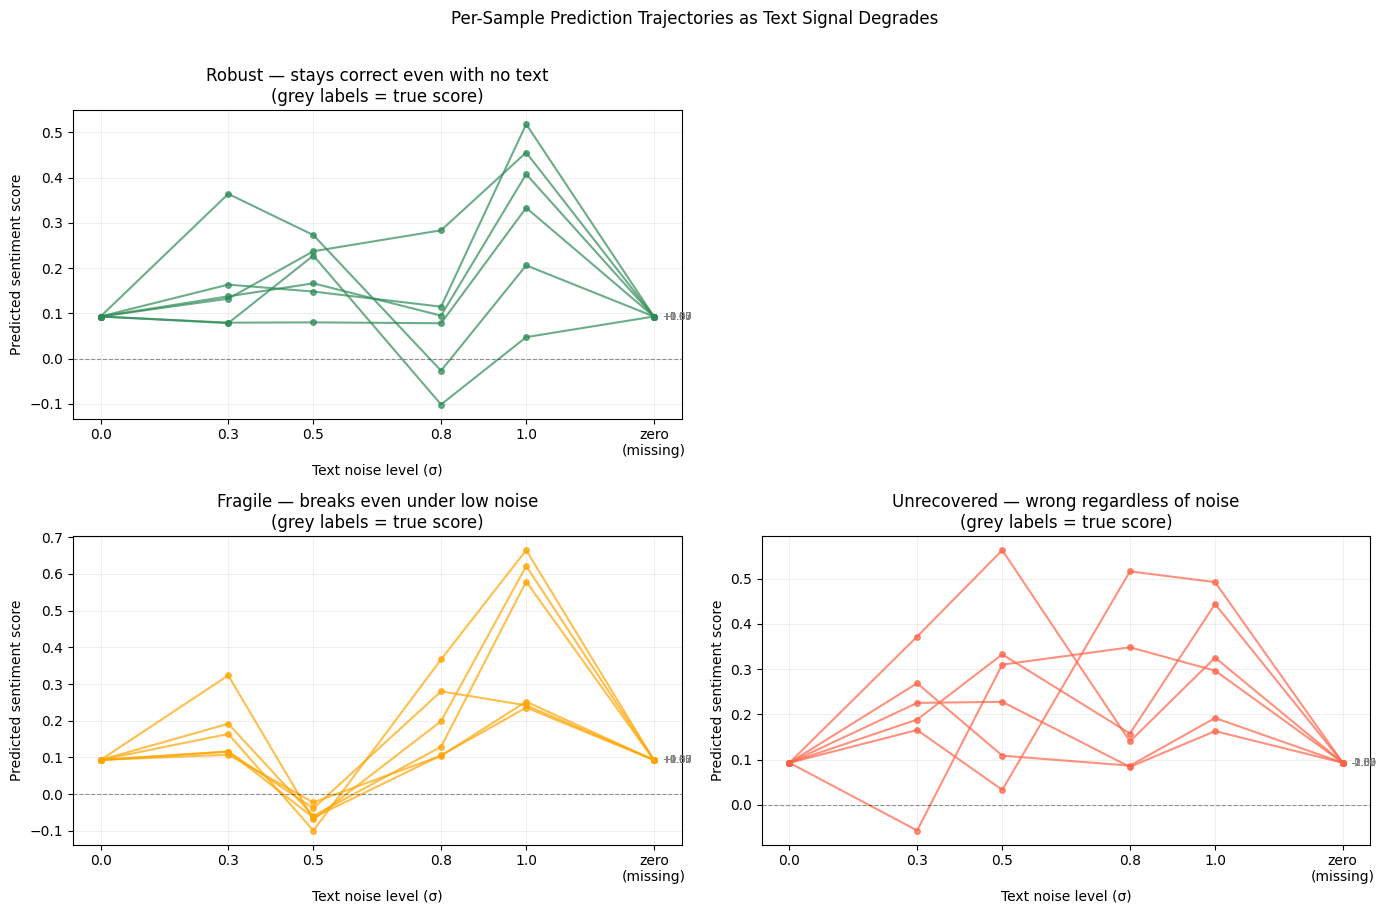

In [ ]:
# ── 4. Individual sample noise trajectories (line plots) ─────────────────────
# Pick 2-3 samples from each recovery category and plot how each sample's
# prediction moves as noise increases toward full text removal.
import matplotlib.pyplot as plt
import numpy as np

x_vals = noise_levels + [1.3]   # 1.3 represents 'zero text' on the x axis
x_labels_plot = [str(nl) for nl in noise_levels] + ['zero\n(missing)']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

tag_config = [
    ('robust ✓',     'seagreen',  'Robust — stays correct even with no text'),
    ('needs text ↓', 'steelblue', 'Needs text — correct only when text is present'),
    ('fragile ⚡',   'orange',    'Fragile — breaks even under low noise'),
    ('wrong ✗',      'tomato',    'Unrecovered — wrong regardless of noise'),
]

all_preds_by_level = [preds_by_noise[nl] for nl in noise_levels] + [preds_zero]

for ax, (tag, color, title) in zip(axes, tag_config):
    subset = df[df['recovery'] == tag]
    if len(subset) == 0:
        ax.set_visible(False)
        continue

    # Pick up to 6 representative samples
    sample_indices = subset.sample(min(6, len(subset)), random_state=42).index.tolist()

    for idx in sample_indices:
        sid        = df.loc[idx, 'utterance_id']
        true_label = df.loc[idx, 'true_label']
        i          = test_sids.index(sid)
        traj = [float(p[i]) for p in all_preds_by_level]

        ax.plot(x_vals, traj, 'o-', alpha=0.7, linewidth=1.5, markersize=4, color=color)
        ax.text(x_vals[-1] + 0.02, traj[-1],
                f'{true_label:+.2f}', fontsize=7, va='center', color='grey')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4, label='sentiment=0')
    ax.set_xticks(x_vals)
    ax.set_xticklabels(x_labels_plot)
    ax.set_xlabel('Text noise level (σ)')
    ax.set_ylabel('Predicted sentiment score')
    ax.set_title(f'{title}\n(grey labels = true score)')
    ax.grid(True, alpha=0.2)

plt.suptitle('Per-Sample Prediction Trajectories as Text Signal Degrades',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_sample_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()


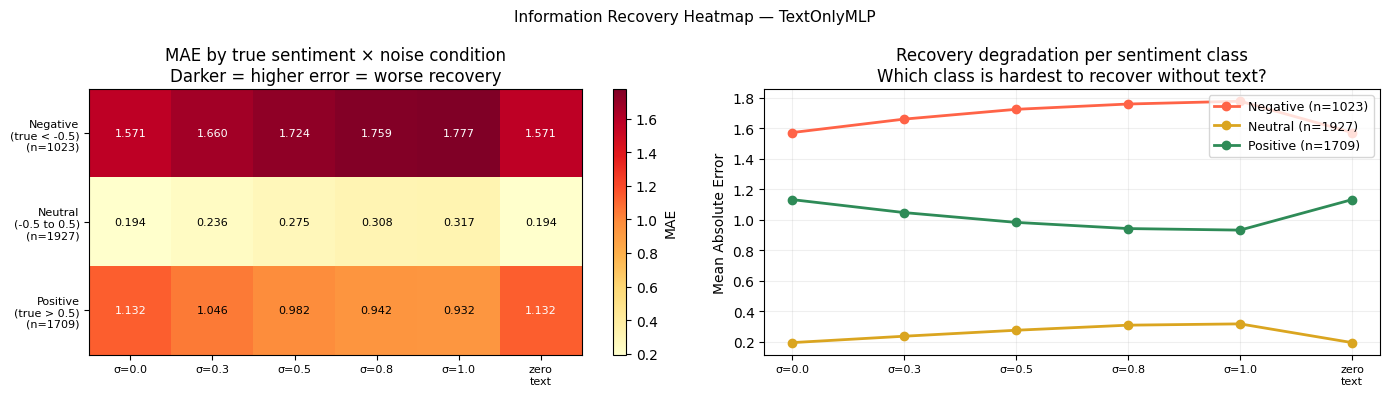

Recovery summary (MAE at zero-text vs clean):
  Negative    clean=1.5714  zero-text=1.5714  degradation=+0.0000
  Neutral     clean=0.1937  zero-text=0.1937  degradation=+0.0000
  Positive    clean=1.1315  zero-text=1.1315  degradation=+0.0000


In [ ]:
# ── 5. Information recovery heatmap ──────────────────────────────────────────
# For each (true_sentiment_bin × noise_level) cell, show the mean absolute error.
# Reveals whether the model recovers positive vs negative vs neutral samples
# differently as the text signal degrades.
import matplotlib.pyplot as plt
import numpy as np

def sentiment_bin(scores):
    bins = np.full(len(scores), 1, dtype=int)   # neutral = 1
    bins[scores >  0.5] = 2  # positive
    bins[scores < -0.5] = 0  # negative
    return bins

true_bins     = sentiment_bin(test_labels)
bin_names     = ['Negative\n(true < -0.5)', 'Neutral\n(-0.5 to 0.5)', 'Positive\n(true > 0.5)']
cond_labels   = [f'σ={nl}' for nl in noise_levels] + ['zero\ntext']

# MAE matrix: shape (3 sentiment bins, 6 conditions)
mae_matrix = np.zeros((3, len(cond_labels)))
count_matrix = np.zeros(3, dtype=int)

for b in range(3):
    mask = true_bins == b
    count_matrix[b] = mask.sum()
    for j, preds in enumerate(all_preds_by_level):
        mae_matrix[b, j] = np.abs(preds[mask] - test_labels[mask]).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
im = axes[0].imshow(mae_matrix, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=axes[0], label='MAE')
axes[0].set_xticks(range(len(cond_labels)))
axes[0].set_xticklabels(cond_labels, fontsize=8)
axes[0].set_yticks(range(3))
axes[0].set_yticklabels([f'{b}\n(n={count_matrix[i]})'
                          for i, b in enumerate(bin_names)], fontsize=8)
axes[0].set_title('MAE by true sentiment × noise condition\n'
                  'Darker = higher error = worse recovery')
for i in range(3):
    for j in range(len(cond_labels)):
        axes[0].text(j, i, f'{mae_matrix[i,j]:.3f}', ha='center', va='center',
                     fontsize=8, color='black' if mae_matrix[i,j] < mae_matrix.max()*0.6 else 'white')

# Line version for clearer trend reading
for b, (bname, color) in enumerate(zip(
    ['Negative', 'Neutral', 'Positive'],
    ['tomato', 'goldenrod', 'seagreen']
)):
    axes[1].plot(range(len(cond_labels)), mae_matrix[b], 'o-',
                 label=f'{bname} (n={count_matrix[b]})', color=color, linewidth=2)
axes[1].set_xticks(range(len(cond_labels)))
axes[1].set_xticklabels(cond_labels, fontsize=8)
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_title('Recovery degradation per sentiment class\n'
                  'Which class is hardest to recover without text?')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.suptitle('Information Recovery Heatmap — TextOnlyMLP', fontsize=11)
plt.tight_layout()
plt.savefig(CSD_DIR + 'text_only_recovery_heatmap.png', dpi=150)
plt.show()

print('Recovery summary (MAE at zero-text vs clean):')
for b, bname in enumerate(['Negative', 'Neutral', 'Positive']):
    delta = mae_matrix[b, -1] - mae_matrix[b, 0]
    print(f'  {bname:<10}  clean={mae_matrix[b,0]:.4f}  '
          f'zero-text={mae_matrix[b,-1]:.4f}  '
          f'degradation=+{delta:.4f}')
